# Dinâmica 03 - Redes Neurais e Controle Industrial
**Unidade Curricular:** Inteligência Artificial  
**Câmpus:** Chapecó  
**Docente:** Dra. Lara Popov Zambiasi Bazzi Oberderfer  

---
## 🎯 Objetivo
Evoluir do aprendizado baseado em tabelas para o **Deep Q-Learning**. O desafio é treinar uma Rede Neural Profunda para atuar como um controlador de estabilidade em um sistema de pêndulo invertido (**CartPole**).
Ambiente CartPole: <https://gymnasium.farama.org/environments/classic_control/cart_pole/>

In [1]:
# =================================================================
# 1. CONFIGURAÇÃO DO MONITOR VIRTUAL (ESSENCIAL PARA O COLAB)
# =================================================================
# O Colab roda em servidores remotos. Precisamos de um "Virtual Display"
# para que o motor físico do Gymnasium possa renderizar os frames.
print("Instalando dependências de vídeo...")
!apt-get install -y xvfb python-opengl ffmpeg > /dev/null 2>&1
!pip install pyvirtualdisplay gymnasium[classic_control] > /dev/null 2>&1

import gymnasium as gym
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import base64
from pyvirtualdisplay import Display
from IPython import display as ipythondisplay

# Inicia o monitor virtual na memória do servidor
v_display = Display(visible=0, size=(1400, 900))
v_display.start()

def show_video():
    """Função auxiliar para exibir o vídeo gravado diretamente no notebook"""
    import glob
    import os
    mp4list = glob.glob('video/*.mp4')
    if len(mp4list) > 0:
        mp4 = mp4list[-1]
        video = open(mp4, 'rb').read()
        encoded = base64.b64encode(video)
        ipythondisplay.display(ipythondisplay.HTML(data='''<video autoplay
                loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{0}" type="video/mp4" />
             </video>'''.format(encoded.decode('ascii'))))
    else: print("Vídeo não encontrado.")

Instalando dependências de vídeo...


### 🧠 Sprint 1: O "Cérebro" Artificial
Diferente do TaxiDriver, o CartPole possui estados contínuos (ângulos decimais).
Utilizaremos uma **Rede Neural MLP** (Multi-Layer Perceptron) para aproximar a função de valor Q.

In [ ]:
class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.gamma = 0.95    # Fator de desconto (importância do futuro)
        self.learning_rate = 0.001
        self.model = self._build_model()

    def _build_model(self):
        """Constrói a arquitetura da rede usando Keras"""
        model = tf.keras.Sequential([
            # Entrada: Recebe os 4 sinais dos sensores (posição, vel, ângulo, vel_ang)
            layers.Input(shape=(self.state_size,)),

            # Camadas Ocultas: Aprendem as correlações não-lineares da física
            layers.Dense(24, activation='relu'),
            layers.Dense(24, activation='relu'),

            # Saída: Prevê a 'qualidade' (Q-Value) para as 2 ações possíveis
            layers.Dense(self.action_size, activation='linear')
        ])
        # Otimizador Adam: Aplica o Gradiente Descendente para minimizar o erro (MSE)
        model.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=self.learning_rate))
        return model

    def train_step(self, state, action, reward, next_state, done):
        """Executa a Retropropagação (Backpropagation)"""
        # Cálculo do alvo (Equação de Bellman)
        target = reward
        if not done:
            # Previsão da recompensa futura máxima
            target = reward + self.gamma * np.max(self.model.predict(next_state, verbose=0))

        # Ajusta apenas o valor da ação que foi tomada
        target_f = self.model.predict(state, verbose=0)
        target_f[0][action] = target

        # O comando fit() ajusta os pesos neurais para diminuir a diferença entre real e previsto
        self.model.fit(state, target_f, epochs=1, verbose=0)

### 📈 Sprint 2: Treinamento por Retropropagação
O agente aprenderá a equilibrar o mastro através de ciclos de tentativa, erro e ajuste de pesos sinápticos.

Iniciando treinamento... O gradiente está otimizando os pesos.
Episódio 10/50 | Estabilidade: 10 frames
Episódio 20/50 | Estabilidade: 10 frames
Episódio 30/50 | Estabilidade: 10 frames
Episódio 40/50 | Estabilidade: 10 frames
Episódio 50/50 | Estabilidade: 10 frames


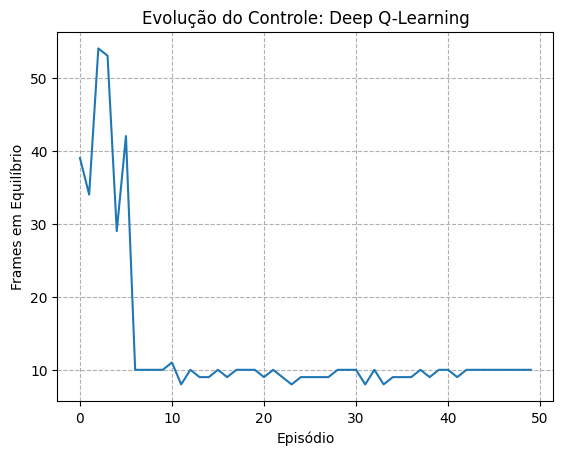

In [ ]:
# Inicialização do ambiente e do agente
env = gym.make("CartPole-v1")
agent = DQNAgent(state_size=4, action_size=2)
episodes = 50
scores = []

print("Iniciando treinamento... O gradiente está otimizando os pesos.")

for e in range(1, episodes + 1):
    state, _ = env.reset()
    state = np.reshape(state, [1, 4])
    time = 0

    while True:
        # A rede 'prevê' a melhor ação para o estado atual
        action = np.argmax(agent.model.predict(state, verbose=0)[0])

        next_state, reward, terminated, truncated, _ = env.step(action)
        next_state = np.reshape(next_state, [1, 4])

        # Treina a rede com o resultado desta ação
        agent.train_step(state, action, reward, next_state, terminated or truncated)

        state = next_state
        time += 1

        if terminated or truncated:
            break

    scores.append(time)
    if e % 10 == 0:
        print(f"Episódio {e}/{episodes} | Estabilidade: {time} frames")

# Gráfico de evolução da estabilidade
plt.plot(scores)
plt.title('Evolução do Controle: Deep Q-Learning')
plt.xlabel('Episódio')
plt.ylabel('Frames em Equilíbrio')
plt.grid(True, linestyle='--')
plt.show()

### 🎬 Sprint 3: Demonstração do Controlador
Visualização do comportamento final do robô utilizando os pesos otimizados.

In [ ]:
# Configura o gravador de vídeo (ignorar avisos de 'Overwriting')
env_video = gym.make("CartPole-v1", render_mode="rgb_array")
env_video = gym.wrappers.RecordVideo(env_video, "./video", episode_trigger=lambda x: True)

state, _ = env_video.reset()
state = np.reshape(state, [1, 4])

for _ in range(300):
    # Escolha da melhor ação baseada na rede treinada
    action = np.argmax(agent.model.predict(state, verbose=0)[0])
    state, _, terminated, truncated, _ = env_video.step(action)
    state = np.reshape(state, [1, 4])
    if terminated or truncated: break

env_video.close()
show_video()

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


# 📝 Ficha de Análise: Dinâmica 03

### Reflexão sobre Deep Learning:

1. **Generalização:** Por que o CartPole exige uma Rede Neural em vez de uma tabela simples como a do Taxi?
2. **Convergência:** Analise o gráfico de frames. O aprendizado foi constante ou houve momentos de instabilidade (quedas bruscas)?
3. **Engenharia:** Como a **Taxa de Aprendizado** influencia na velocidade com que o carrinho aprende a se equilibrar?
4. **Aplicação Industrial:** Cite um exemplo de sistema real de controle que poderia ser otimizado com esta técnica de Redes Neurais.